<a href="https://colab.research.google.com/github/ibrayks/Proyecto-DataXperience-Bogota/blob/main/Proyecto_DataXperience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas seaborn matplotlib statsmodels scikit-learn openpyxl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
print("¡Todo listo!")

¡Todo listo!


Original shape: (9520, 8)
0       $ 360.000.000
1       $ 670.000.000
2     $ 1.120.000.000
3       $ 890.000.000
4       $ 970.000.000
5       $ 510.000.000
6       $ 500.000.000
7     $ 2.350.000.000
8       $ 850.000.000
9       $ 642.000.000
10      $ 652.000.000
11      $ 168.000.000
12      $ 205.000.000
13      $ 300.000.000
14      $ 680.000.000
15    $ 2.519.000.000
16      $ 420.000.000
17      $ 620.000.000
18      $ 239.000.000
19    $ 1.600.000.000
Name: Valor, dtype: object

Shape después: (5945, 8)
       Habitaciones        Baños           Área         Valor
count   5945.000000  5945.000000    5945.000000  5.945000e+03
mean       3.158789     2.545669     165.736754  6.545029e+08
std        2.312705     1.292634    2175.883092  7.653919e+08
min        1.000000     0.000000       2.000000  6.000000e+07
25%        2.000000     2.000000      60.000000  2.750000e+08
50%        3.000000     2.000000      87.000000  4.490000e+08
75%        3.000000     3.000000     151.000000

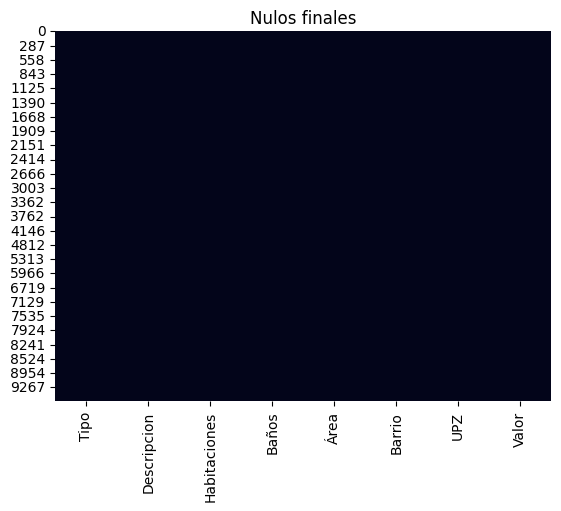

In [6]:
# Cargar de nuevo (por si acaso)
df = pd.read_csv('inmuebles_bogota.csv')

print("Original shape:", df.shape)
print(df['Valor'].head(20))  # ← ¡Mira esto! Muestra los primeros 20 valores de Valor

# Limpieza mejorada de 'Valor'
df['Valor'] = df['Valor'].astype(str).str.strip()
df['Valor'] = df['Valor'].str.replace(r'[\$\.]', '', regex=True)  # quita $ y puntos
df['Valor'] = df['Valor'].str.replace(',', '.', regex=False)      # coma → punto decimal si hay
df['Valor'] = pd.to_numeric(df['Valor'], errors='coerce')

# Área (por si acaso)
df['Área'] = pd.to_numeric(df['Área'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Eliminar duplicados
df = df.drop_duplicates()

# Imputar nulos
df['Habitaciones'] = df['Habitaciones'].fillna(df['Habitaciones'].median())
df['Baños'] = df['Baños'].fillna(df['Baños'].median())
df['Área'] = df['Área'].fillna(df['Área'].mean())
# UPZ: lo dejamos como está o lo ponemos 'Sin UPZ'
df['UPZ'] = df['UPZ'].fillna('Sin UPZ')

# Eliminar solo filas sin Valor válido
df = df.dropna(subset=['Valor'])

print("\nShape después:", df.shape)
print(df.describe())
print("\nPrimeros Valores limpios:", df['Valor'].head(10))

# Mapa nulos final
sns.heatmap(df.isnull(), cbar=False)
plt.title("Nulos finales")
plt.show()

df.to_csv('bogota_inmuebles_limpio_v2.csv', index=False)

Valor (precio):
Media: 654502922.9170731
Mediana: 449000000.0
Moda: 450000000
Rango: 15940000000
Desviación estándar: 765391885.420602
Barrio
Alameda                  5.800000e+08
Alhambra                 7.338462e+08
Andes Norte              7.264000e+08
Antonio Nariño           4.881468e+08
Barrancas                3.341250e+08
Barrios Unidos           5.439774e+08
Bella Suiza              7.736485e+08
Bellavista Occidental    7.650000e+08
Bochica                  7.050000e+08
Bogotá D.C               6.973929e+08
Name: Valor, dtype: float64


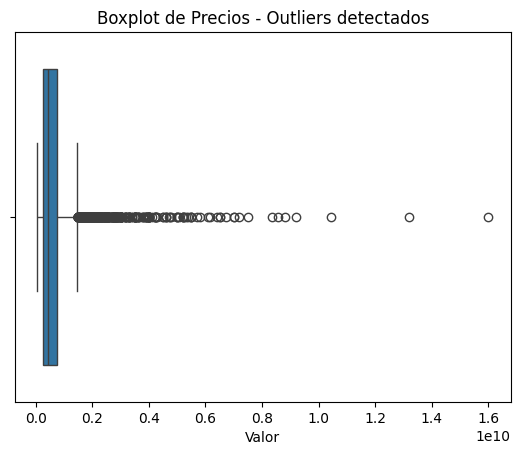

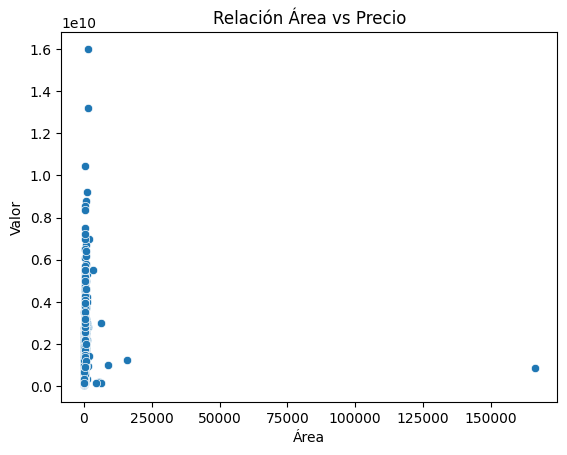

In [7]:
# Medidas de tendencia central y dispersión (solo numéricas)
print("Valor (precio):")
print("Media:", df['Valor'].mean())
print("Mediana:", df['Valor'].median())
print("Moda:", df['Valor'].mode()[0])
print("Rango:", df['Valor'].max() - df['Valor'].min())
print("Desviación estándar:", df['Valor'].std())

# Comparación entre barrios (ejemplo)
print(df.groupby('Barrio')['Valor'].mean().head(10))

# Outliers y relaciones
sns.boxplot(x=df['Valor'])
plt.title("Boxplot de Precios - Outliers detectados")
plt.show()

sns.scatterplot(x='Área', y='Valor', data=df)
plt.title("Relación Área vs Precio")
plt.show()

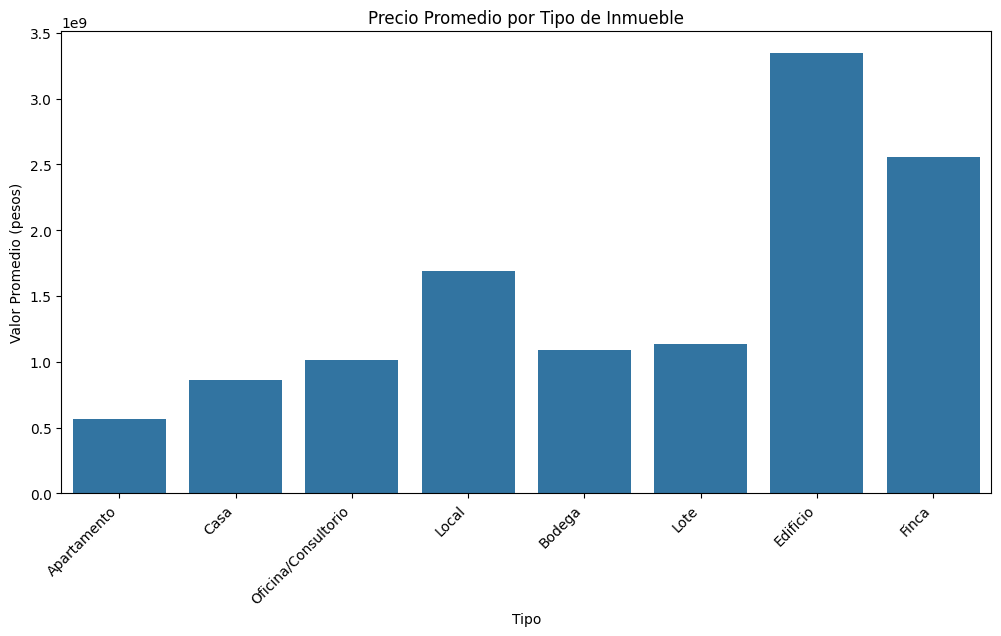

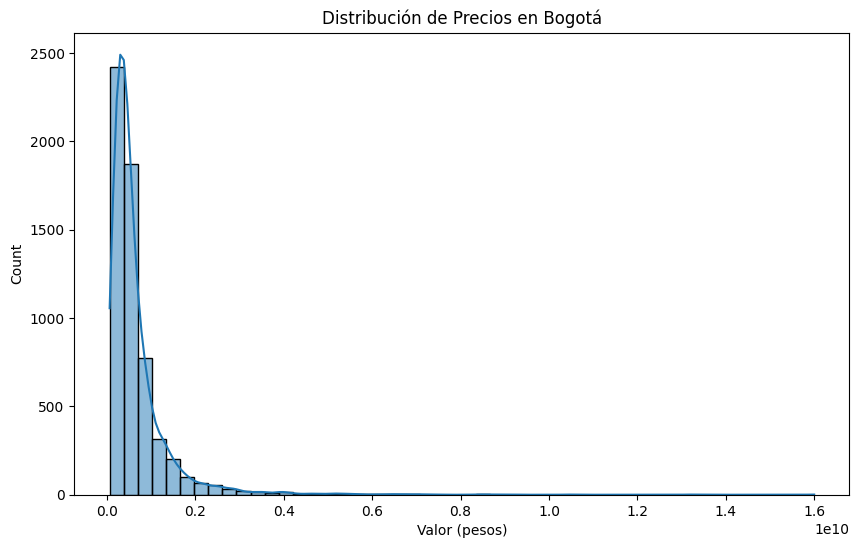

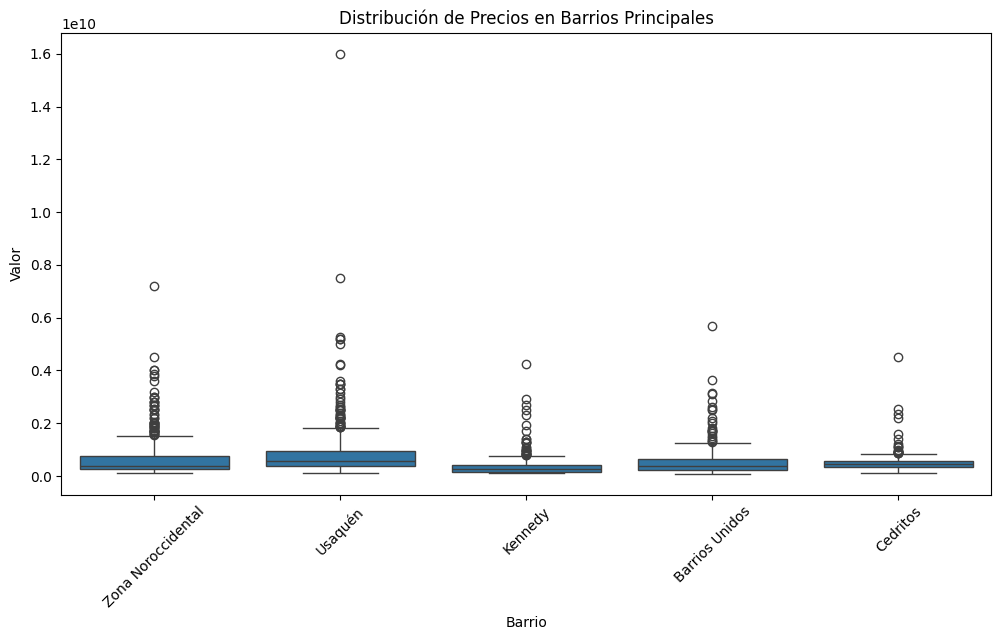

Resultados del Modelo:
R² (qué tan bien explica el modelo): 0.34550426294575165
Error cuadrático medio: 2.5359346866703405e+17

Coeficientes (impacto de cada variable):
               Coeficiente
Área          6.653482e+03
Habitaciones -1.274203e+07
Baños         3.523011e+08


In [9]:
import numpy as np  # ← IMPORTANTE: agrégalo aquí

# 1. Barras: Precio promedio por tipo
plt.figure(figsize=(12,6))
sns.barplot(x='Tipo', y='Valor', data=df, estimator=np.mean, errorbar=None)
plt.xticks(rotation=45, ha='right')
plt.title("Precio Promedio por Tipo de Inmueble")
plt.ylabel("Valor Promedio (pesos)")
plt.show()

# 2. Histograma de precios
plt.figure(figsize=(10,6))
sns.histplot(df['Valor'], bins=50, kde=True)
plt.title("Distribución de Precios en Bogotá")
plt.xlabel("Valor (pesos)")
plt.show()

# 3. Boxplot por barrios top (5 con más propiedades)
top_barrios = df['Barrio'].value_counts().head(5).index
plt.figure(figsize=(12,6))
sns.boxplot(x='Barrio', y='Valor', data=df[df['Barrio'].isin(top_barrios)])
plt.xticks(rotation=45)
plt.title("Distribución de Precios en Barrios Principales")
plt.show()

# Modelo: Regresión Lineal
X = df[['Área', 'Habitaciones', 'Baños']]
y = df['Valor']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Resultados del Modelo:")
print("R² (qué tan bien explica el modelo):", r2_score(y_test, y_pred))
print("Error cuadrático medio:", mean_squared_error(y_test, y_pred))

# Coeficientes
coeficientes = pd.DataFrame(model.coef_, X.columns, columns=['Coeficiente'])
print("\nCoeficientes (impacto de cada variable):")
print(coeficientes)